In [ ]:
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Для изображения sar_3.jpg найти наиболее протяженный участок

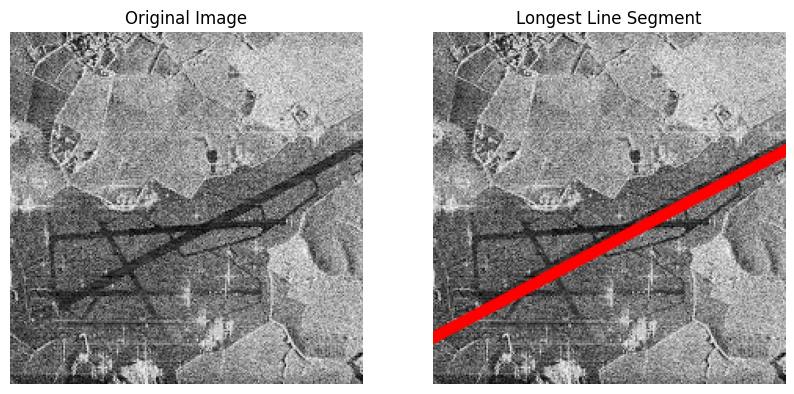

In [10]:
# Прямой Hough + выбор наиболее протяжённого участка (упрощённый, как в примере)
image_path = 'sar_3.jpg'
image = cv2.imread(image_path)

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

canny = cv2.Canny(image_gray, 100, 150, apertureSize=3)
lines = cv2.HoughLines(canny, 1, np.pi / 180, 135)

max_length = 0
longest_line = None

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
        pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))
        length = np.hypot(pt1[0] - pt2[0], pt1[1] - pt2[1])
        if length > max_length:
            max_length = length
            longest_line = (pt1, pt2)

image_with_line = image.copy()
if longest_line is not None:
    cv2.line(image_with_line, longest_line[0], longest_line[1], (0, 0, 255), 6, cv2.LINE_AA)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image_with_line, cv2.COLOR_BGR2RGB))
plt.title('Longest Line Segment')
plt.axis('off')
plt.show()

# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

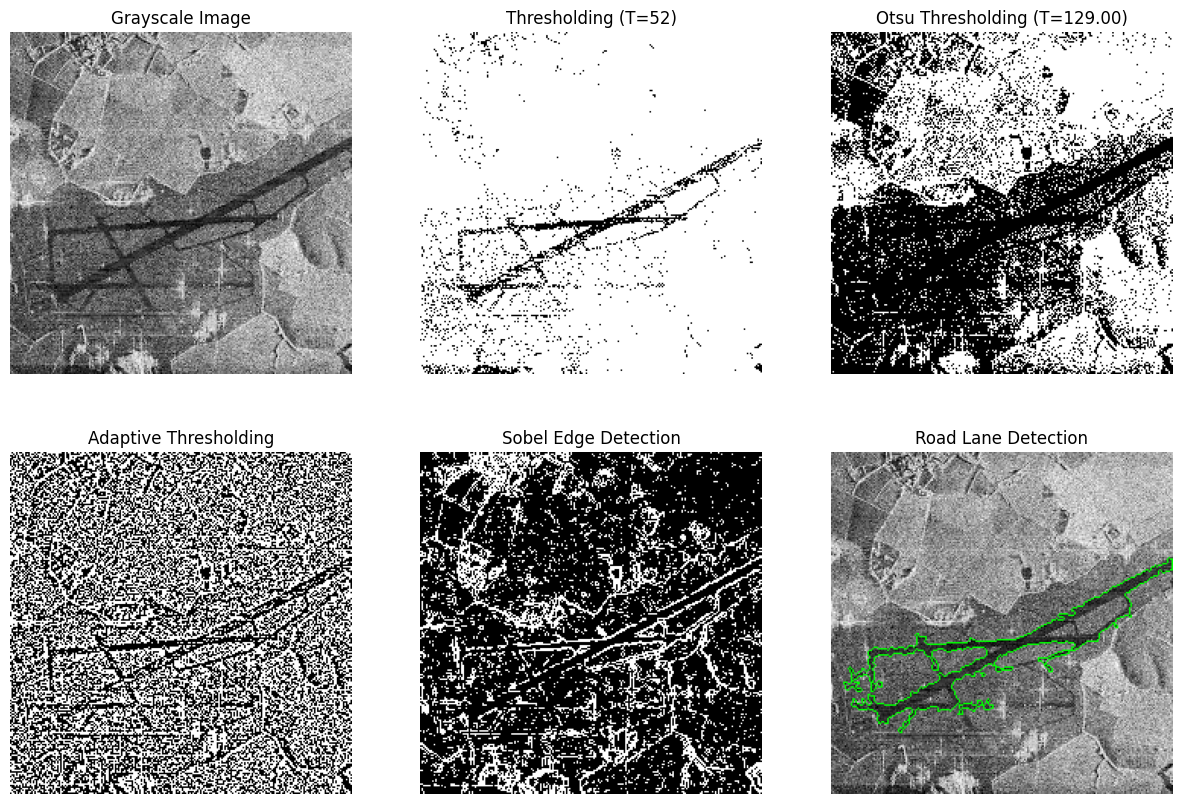

In [49]:
# Точечная бинаризация
thresh_value = 52
bin_image = cv2.threshold(image_gray, thresh_value, 255, cv2.THRESH_BINARY)[1]

# Бинаризация методом Оцу
otsu_thresh_value, otsu_bin_image = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Адаптивная бинаризация
adaptive_bin_image = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                             cv2.THRESH_BINARY, 11, 2)

# Оператор Собеля
sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)
sobel_magnitude_u8 = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
otsu_sobel_val, sobel_bin_image = cv2.threshold(sobel_magnitude_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Выделение дорожной полосы
blurred = cv2.GaussianBlur(bin_image, (5, 5), 0)
thresh_value_two = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 53, 2)
countours, _ = cv2.findContours(thresh_value_two, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
road_image = image.copy()
for contour in countours:
    if cv2.contourArea(contour) > 500:
        cv2.drawContours(road_image, [contour], -1, (0, 255, 0), 1)

plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(bin_image, cmap='gray')
plt.title(f'Thresholding (T={thresh_value})')
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(otsu_bin_image, cmap='gray')
plt.title(f'Otsu Thresholding (T={otsu_thresh_value:.2f})')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(adaptive_bin_image, cmap='gray')
plt.title('Adaptive Thresholding')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.imshow(sobel_bin_image, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(road_image, cv2.COLOR_BGR2RGB))
plt.title('Road Lane Detection')
plt.axis('off')

plt.show()
